<a href="https://colab.research.google.com/github/sainiveditha04/FUTURE_ML_01/blob/main/sales_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sales & Demand Forecasting

This notebook predicts future monthly sales for a retail superstore based on 4 years of historical order data, and presents the forecast in a way a store owner or business manager can act on.

**Dataset:** Superstore sales data — 9,800 orders from 2015-2018.

**What this notebook covers:**
1. Data cleaning
2. Time-based feature engineering (trend + seasonality)
3. A regression forecasting model, evaluated on a held-out test period
4. A 12-month forecast with business-friendly visualization
5. A plain-language explanation of what the forecast means

## 1. Load the Dataset

Pulling the CSV directly from the GitHub repo via its raw URL - no manual upload needed, and it runs identically for anyone who opens it.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

url = "https://raw.githubusercontent.com/sainiveditha04/FUTURE_ML_01/main/train.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
df.head()

Shape: (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


## 2. Data Cleaning - Check for Missing Values

Before doing anything else, check what's missing. This matters because a model built on dirty data gives a confident-looking but untrustworthy forecast.

In [2]:
missing = df.isnull().sum()
print(missing[missing > 0])

Postal Code    11
dtype: int64


**Finding:** Only `Postal Code` has missing values (11 rows), and it isn't used anywhere in this forecast - we only need `Order Date` and `Sales`, and both are fully populated. No imputation or row-dropping is needed for the columns this model actually depends on.

## 3. Convert Dates and Aggregate to Monthly Sales

`Order Date` is stored as text in `DD/MM/YYYY` format, so `dayfirst=True` is required - without it, pandas silently misreads days as months for any day under 12, corrupting the whole timeline.

Individual orders are then grouped into monthly totals, since the forecast operates at a monthly granularity (matching how a business plans inventory and staffing).

In [3]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

monthly_sales.index = monthly_sales.index.to_timestamp()

monthly_df = monthly_sales.reset_index()
monthly_df.columns = ['Date', 'Sales']

print("Number of months:", len(monthly_df))
monthly_df.head()

Number of months: 48


,Date,Sales
0,2015-01-01,14205.707
1,2015-02-01,4519.892
2,2015-03-01,55205.797
3,2015-04-01,27906.855
4,2015-05-01,23644.303


### Monthly Sales Trend

A first look at the data before modeling anything.

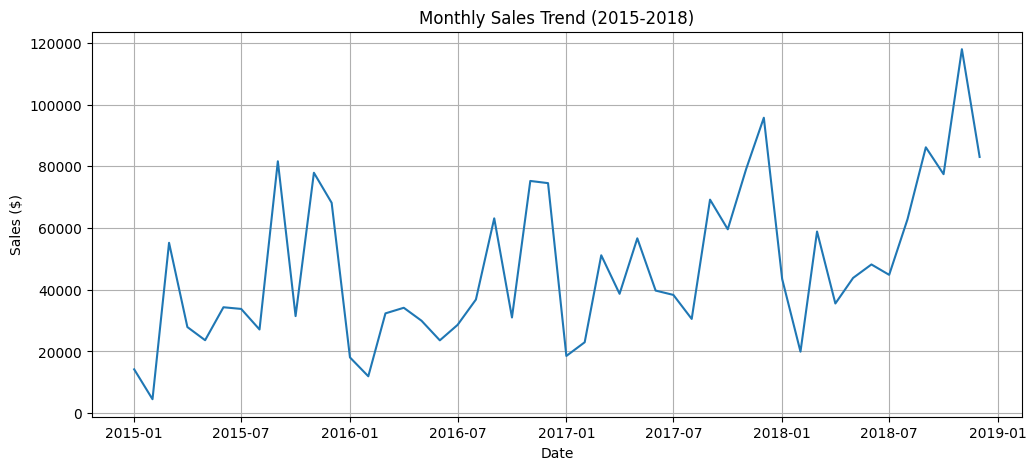

In [4]:
plt.figure(figsize=(12,5))
plt.plot(monthly_df['Date'], monthly_df['Sales'])
plt.title("Monthly Sales Trend (2015-2018)")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.grid(True)
plt.show()

## 4. Time-Based Feature Engineering: Trend + Seasonality

Two kinds of signal drive monthly sales:

- **Trend** - captured with `Month_Number`, a simple counter (0, 1, 2, ...) that lets the model learn whether sales are generally rising or falling over time.
- **Seasonality** - captured with `Month_of_Year` (1-12), one-hot encoded. Retail sales are rarely flat across the calendar - November/December spikes from holiday shopping are a textbook example. Without this feature, the model can only draw a straight line and will systematically under-predict peak months and over-predict slow months.

`drop_first=True` avoids the dummy-variable trap (perfect multicollinearity between the dummy columns).

In [5]:
monthly_df['Month_Number'] = np.arange(len(monthly_df))
monthly_df['Month_of_Year'] = monthly_df['Date'].dt.month

month_dummies = pd.get_dummies(
    monthly_df['Month_of_Year'],
    prefix='Month',
    drop_first=True
)

features_df = pd.concat(
    [monthly_df[['Month_Number']], month_dummies],
    axis=1
)

features_df.head()

,Month_Number,Month_2,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
0,0,False,False,False,False,False,False,False,False,False,False,False
1,1,True,False,False,False,False,False,False,False,False,False,False
2,2,False,True,False,False,False,False,False,False,False,False,False
3,3,False,False,True,False,False,False,False,False,False,False,False
4,4,False,False,False,True,False,False,False,False,False,False,False


## 5. Train/Test Split (Chronological)

For time-series data, splitting randomly would leak future information into training. Instead, the **last 6 months are held out as a test set** - the model trains only on data *before* that window, then is asked to predict it. This mirrors how the model will actually be used: trained on the past, predicting the unseen future.

In [6]:
n_test = 6
n_train = len(monthly_df) - n_test

X_train = features_df.iloc[:n_train]
y_train = monthly_df['Sales'].iloc[:n_train]

X_test = features_df.iloc[n_train:]
y_test = monthly_df['Sales'].iloc[n_train:]

print("Train months:", len(X_train))
print("Test months:", len(X_test))

Train months: 42
Test months: 6


## 6. Train the Forecasting Model

Linear Regression with the trend + seasonality features defined above.

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained.")

Model trained.


## 7. Evaluate on the Held-Out Test Months

This is the honest accuracy check: how far off was the model on 6 real months it never saw during training?

- **MAE (Mean Absolute Error)** - average dollar amount the forecast was off by, in the same units as sales. Easy to explain to a non-technical stakeholder: "on average, the forecast misses by about $X."
- **MAPE (Mean Absolute Percentage Error)** - the same error expressed as a percentage, which is often more intuitive: "the forecast is typically within Y% of actual sales."

In [8]:
test_predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, test_predictions)
mape = mean_absolute_percentage_error(y_test, test_predictions) * 100

print("Test MAE:", round(mae, 2))
print("Test MAPE:", round(mape, 2), "%")

Test MAE: 14681.46
Test MAPE: 17.67 %


### Visualize Actual vs. Predicted (Test Period)

Seeing the gap visually matters more than the raw number - it shows *where* the model struggles (e.g. underestimating a sharp spike) rather than just *how much* it's off on average.

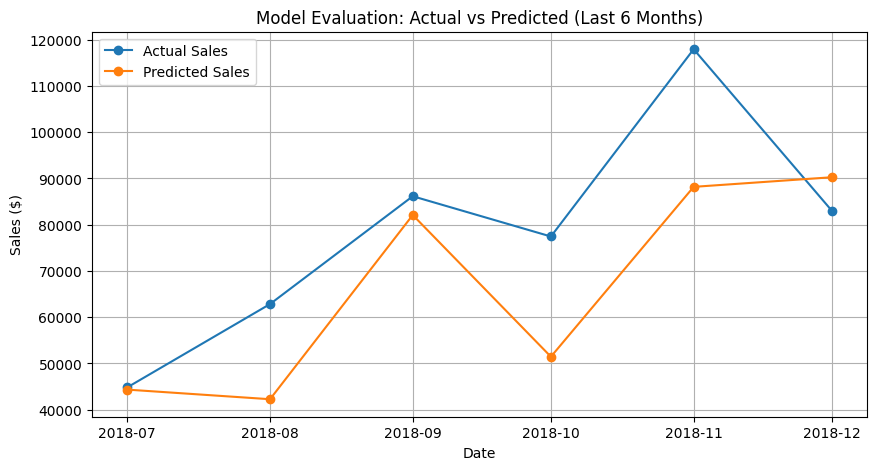

In [9]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_df['Date'].iloc[n_train:],
    y_test,
    marker='o',
    label='Actual Sales'
)
plt.plot(
    monthly_df['Date'].iloc[n_train:],
    test_predictions,
    marker='o',
    label='Predicted Sales'
)

plt.title("Model Evaluation: Actual vs Predicted (Last 6 Months)")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.legend()
plt.grid(True)
plt.show()

## 8. Refit on Full Data and Forecast the Next 12 Months

Now that the model's accuracy has been honestly measured on unseen data, it's refit on **all** available months (including the test period) so the actual forecast benefits from the most recent data - then used to predict 12 months beyond the dataset's end.

In [10]:
final_model = LinearRegression()
final_model.fit(features_df, monthly_df['Sales'])

future_month_numbers = np.arange(
    len(monthly_df),
    len(monthly_df) + 12
)

future_dates = pd.date_range(
    start=monthly_df['Date'].max(),
    periods=13,
    freq='MS'
)[1:]

future_month_of_year = future_dates.month

future_df = pd.DataFrame({
    'Month_Number': future_month_numbers,
    'Month_of_Year': future_month_of_year
})

future_dummies = pd.get_dummies(
    future_df['Month_of_Year'],
    prefix='Month',
    drop_first=True
)
future_dummies = future_dummies.reindex(
    columns=month_dummies.columns,
    fill_value=0
)

future_features = pd.concat(
    [future_df[['Month_Number']], future_dummies],
    axis=1
)

future_predictions = final_model.predict(future_features)

forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecasted_Sales': future_predictions
})

forecast_df

,Date,Forecasted_Sales
0,2019-01-01,41642.573606
1,2019-02-01,32912.445056
2,2019-03-01,67463.063006
3,2019-04-01,52140.416356
4,2019-05-01,56591.347131
5,2019-06-01,54529.047031
6,2019-07-01,54453.588456
7,2019-08-01,57398.647956
8,2019-09-01,93095.519131
9,2019-10-01,67943.739881


## 9. Business-Friendly Forecast Visualization

Actual history and the forecast in one chart, with the forecast period clearly marked - designed so a store owner can glance at it and immediately see "here's what already happened, here's what we expect next."

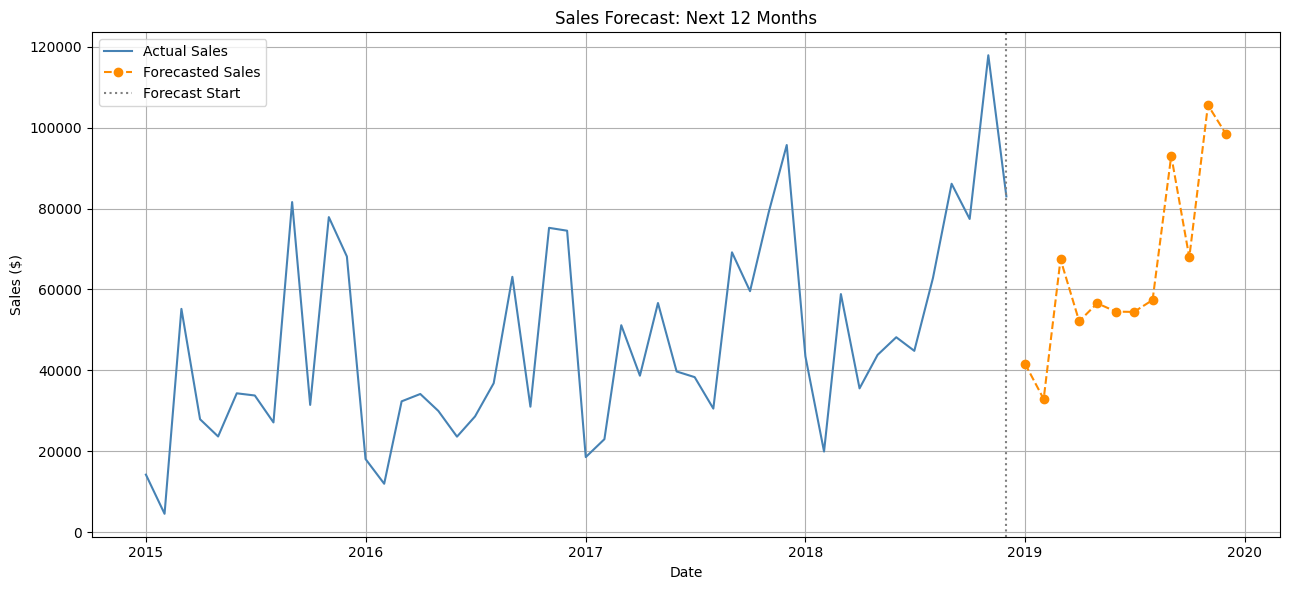

In [11]:
plt.figure(figsize=(13,6))

plt.plot(
    monthly_df['Date'],
    monthly_df['Sales'],
    label='Actual Sales',
    color='steelblue'
)

plt.plot(
    forecast_df['Date'],
    forecast_df['Forecasted_Sales'],
    label='Forecasted Sales',
    color='darkorange',
    linestyle='--',
    marker='o'
)

plt.axvline(
    monthly_df['Date'].max(),
    color='gray',
    linestyle=':',
    label='Forecast Start'
)

plt.title("Sales Forecast: Next 12 Months")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 10. What This Forecast Means for the Business

**What the forecast shows:** Based on four years of order history, monthly sales follow a gradual upward trend combined with a recurring seasonal pattern - sales consistently dip in the early months of the year (January-February) and peak around September and November-December, in line with typical retail holiday-shopping seasonality. The forecast extends that learned pattern 12 months forward.

**How a business can use it:**
- **Inventory planning** - stock up ahead of the predicted September and November/December peaks rather than reacting after demand spikes; ease off ordering ahead of the January/February dip.
- **Staffing** - schedule more seasonal staff for the high-forecast months, fewer for the low ones.
- **Budgeting/cash flow** - anticipate lower revenue months so they aren't mistaken for a problem, and plan larger marketing or hiring budgets around the months the forecast flags as high-demand.
- **Realistic confidence** - the test-period MAPE above gives a concrete "the forecast is typically within ~X% of actuals" figure, so the business knows how much buffer to build into any plan based on this number rather than treating it as exact.

## Summary

- **Data cleaning:** confirmed no missing values in the columns this model depends on (`Order Date`, `Sales`).
- **Feature engineering:** trend (`Month_Number`) + seasonality (`Month_of_Year`, one-hot encoded) - critical for retail data, where flat trend-only models miss holiday-season swings entirely.
- **Evaluation:** Linear Regression tested on 6 held-out months it never trained on, reported with both MAE (dollar terms) and MAPE (percentage terms).
- **Forecast:** 12 months ahead, refit on the full dataset, visualized with a clear actual/forecast split line.
- **Business framing:** translated into concrete inventory, staffing, and budgeting actions rather than left as raw numbers.

**Next steps for a more advanced version:** a dedicated time-series model (e.g. SARIMA or Prophet) to capture seasonality more flexibly than fixed monthly dummies, and prediction intervals (not just point forecasts) so the business can see a confidence range rather than a single number.